# Decision Tree — Klasifikasi Kanker Payudara (scikit-learn dataset)

Notebook ini memakai dataset bawaan scikit-learn: **Breast Cancer Wisconsin**.

## Apa yang diklasifikasikan?
- **Target**: `malignant` (ganas) vs `benign` (jinak)
- **Fitur**: 30 fitur numerik hasil pengukuran sel (mis. `mean radius`, `mean texture`, dll.)

## Tujuan
- Melatih model `DecisionTreeClassifier`
- Mengukur performa di train dan test
- Melihat confusion matrix + classification report
- (Opsional) melihat bentuk pohon (dibatasi `max_depth` supaya tidak terlalu besar)

In [1]:
# (Opsional) install dependency jika kernel belum punya
%pip -q install scikit-learn matplotlib seaborn pandas numpy

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

sns.set_theme(style='whitegrid')
np.random.seed(42)

In [4]:
# Load dataset (sudah tersedia di scikit-learn)
data = load_breast_cancer()
X = data.data
y = data.target
feature_names = data.feature_names
target_names = data.target_names  # ['malignant', 'benign']

df = pd.DataFrame(X, columns=feature_names)
df['target'] = y
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


## Split train/test
Kita pakai `stratify=y` supaya proporsi kelas di train dan test tetap mirip.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)
X_train.shape, X_test.shape

((398, 30), (171, 30))

## Latih Decision Tree (dibatasi kedalamannya)
Tanpa batasan, Decision Tree bisa sangat dalam dan mudah overfit.
Di sini kita batasi `max_depth=3` agar lebih sederhana dan mudah dibaca.

In [11]:
clf = DecisionTreeClassifier(max_depth=None, random_state=42)
clf.fit(X_train, y_train)

pred_train = clf.predict(X_train)
pred_test = clf.predict(X_test)

train_acc = accuracy_score(y_train, pred_train)
test_acc = accuracy_score(y_test, pred_test)
print(f'Train accuracy: {train_acc:.3f}')
print(f'Test  accuracy: {test_acc:.3f}')

Train accuracy: 1.000
Test  accuracy: 0.918


In [12]:
# Classification report
print(classification_report(y_test, pred_test, target_names=target_names))

              precision    recall  f1-score   support

   malignant       0.89      0.89      0.89        64
      benign       0.93      0.93      0.93       107

    accuracy                           0.92       171
   macro avg       0.91      0.91      0.91       171
weighted avg       0.92      0.92      0.92       171



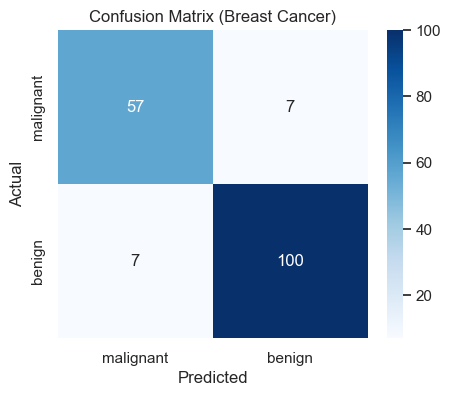

In [13]:
# Confusion matrix
cm = confusion_matrix(y_test, pred_test)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (Breast Cancer)')
plt.show()

## Visualisasi pohon (tree)
Karena kita batasi `max_depth=3`, visualisasi masih cukup ringkas.

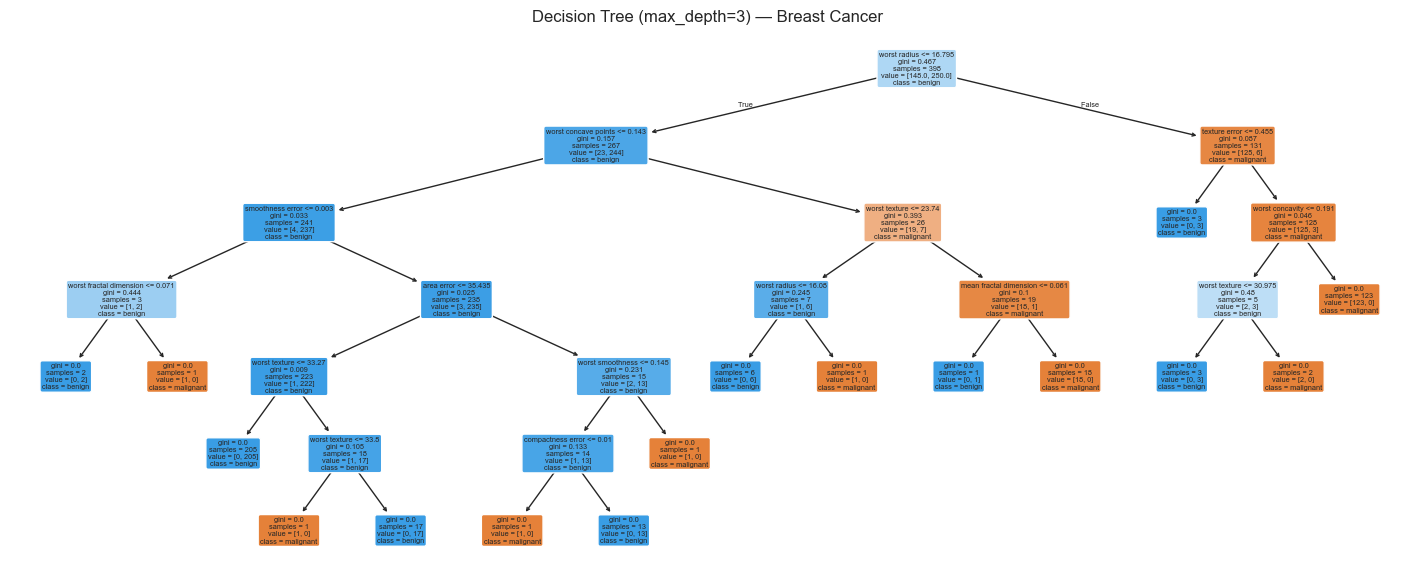

In [14]:
plt.figure(figsize=(18, 7))
plot_tree(
    clf,
    feature_names=list(feature_names),
    class_names=list(target_names),
    filled=True,
    rounded=True,
    impurity=True
)
plt.title('Decision Tree (max_depth=3) — Breast Cancer')
plt.show()

## Catatan: faktor yang mempengaruhi underfit/overfit
- `max_depth` kecil → model sederhana → bisa **underfit**
- `max_depth` besar/None → model kompleks → bisa **overfit**
- `min_samples_leaf` dan `min_samples_split` yang lebih besar → cenderung mengurangi overfit
- `ccp_alpha` (pruning) → memangkas tree → mengurangi overfit